# Plot: per-patient volcano plots

Same per-patient coefficient table, plotted as effect size vs. significance (volcano), one panel per patient.

In [1]:
import pathlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from notebook_init_utils import init_notebook

warnings.filterwarnings("ignore")
root_dir, in_notebook = init_notebook()

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 50)

figures_path = pathlib.Path(
    root_dir, "4.linear_modeling/figures/per_patient_variate_importance"
)
figures_path.mkdir(parents=True, exist_ok=True)
results_path = pathlib.Path(
    root_dir, "4.linear_modeling/results/per_patient_variate_importance"
)

PVALUE_MAX = 0.05


def load_coefficients(profile_name):
    df = pd.read_parquet(
        results_path / f"{profile_name}_per_patient_coefficients.parquet"
    )
    df["significant"] = df["pvalue_fdr"] < PVALUE_MAX
    df["neg_log10_pvalue_fdr"] = -np.log10(df["pvalue_fdr"].clip(lower=1e-300))
    return df


coef_dfs = {name: load_coefficients(name) for name in ["organoid", "single_cell"]}

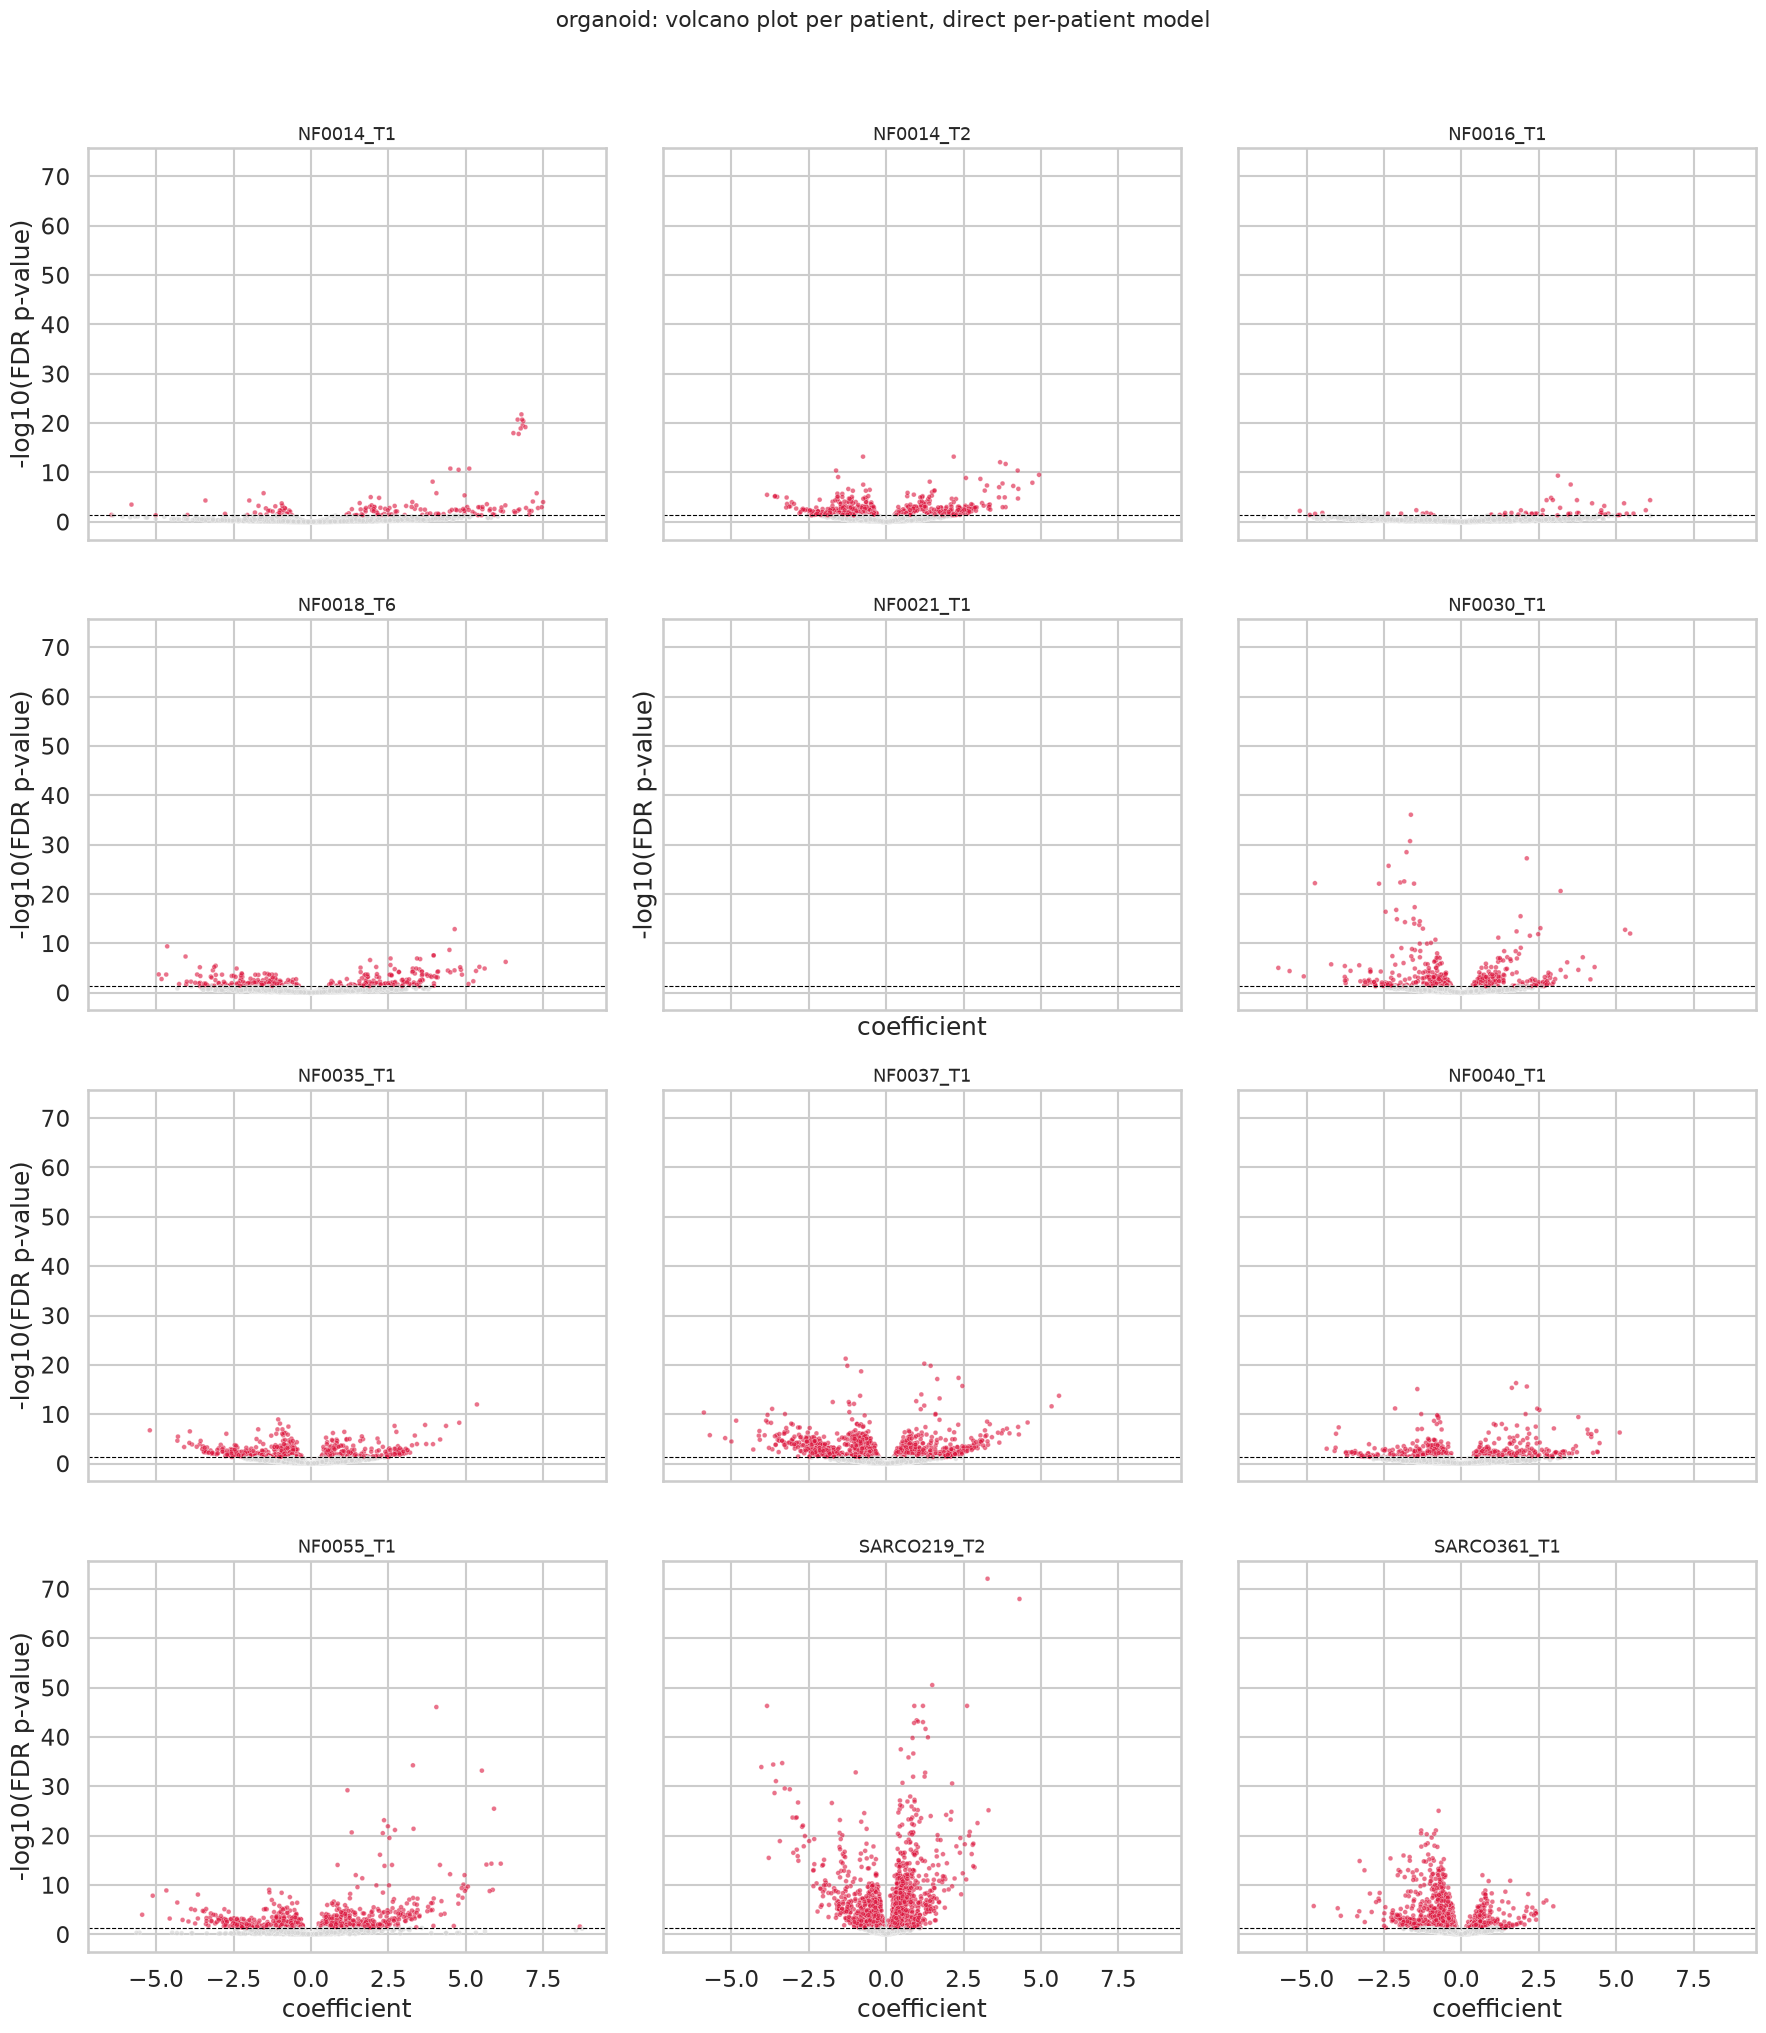

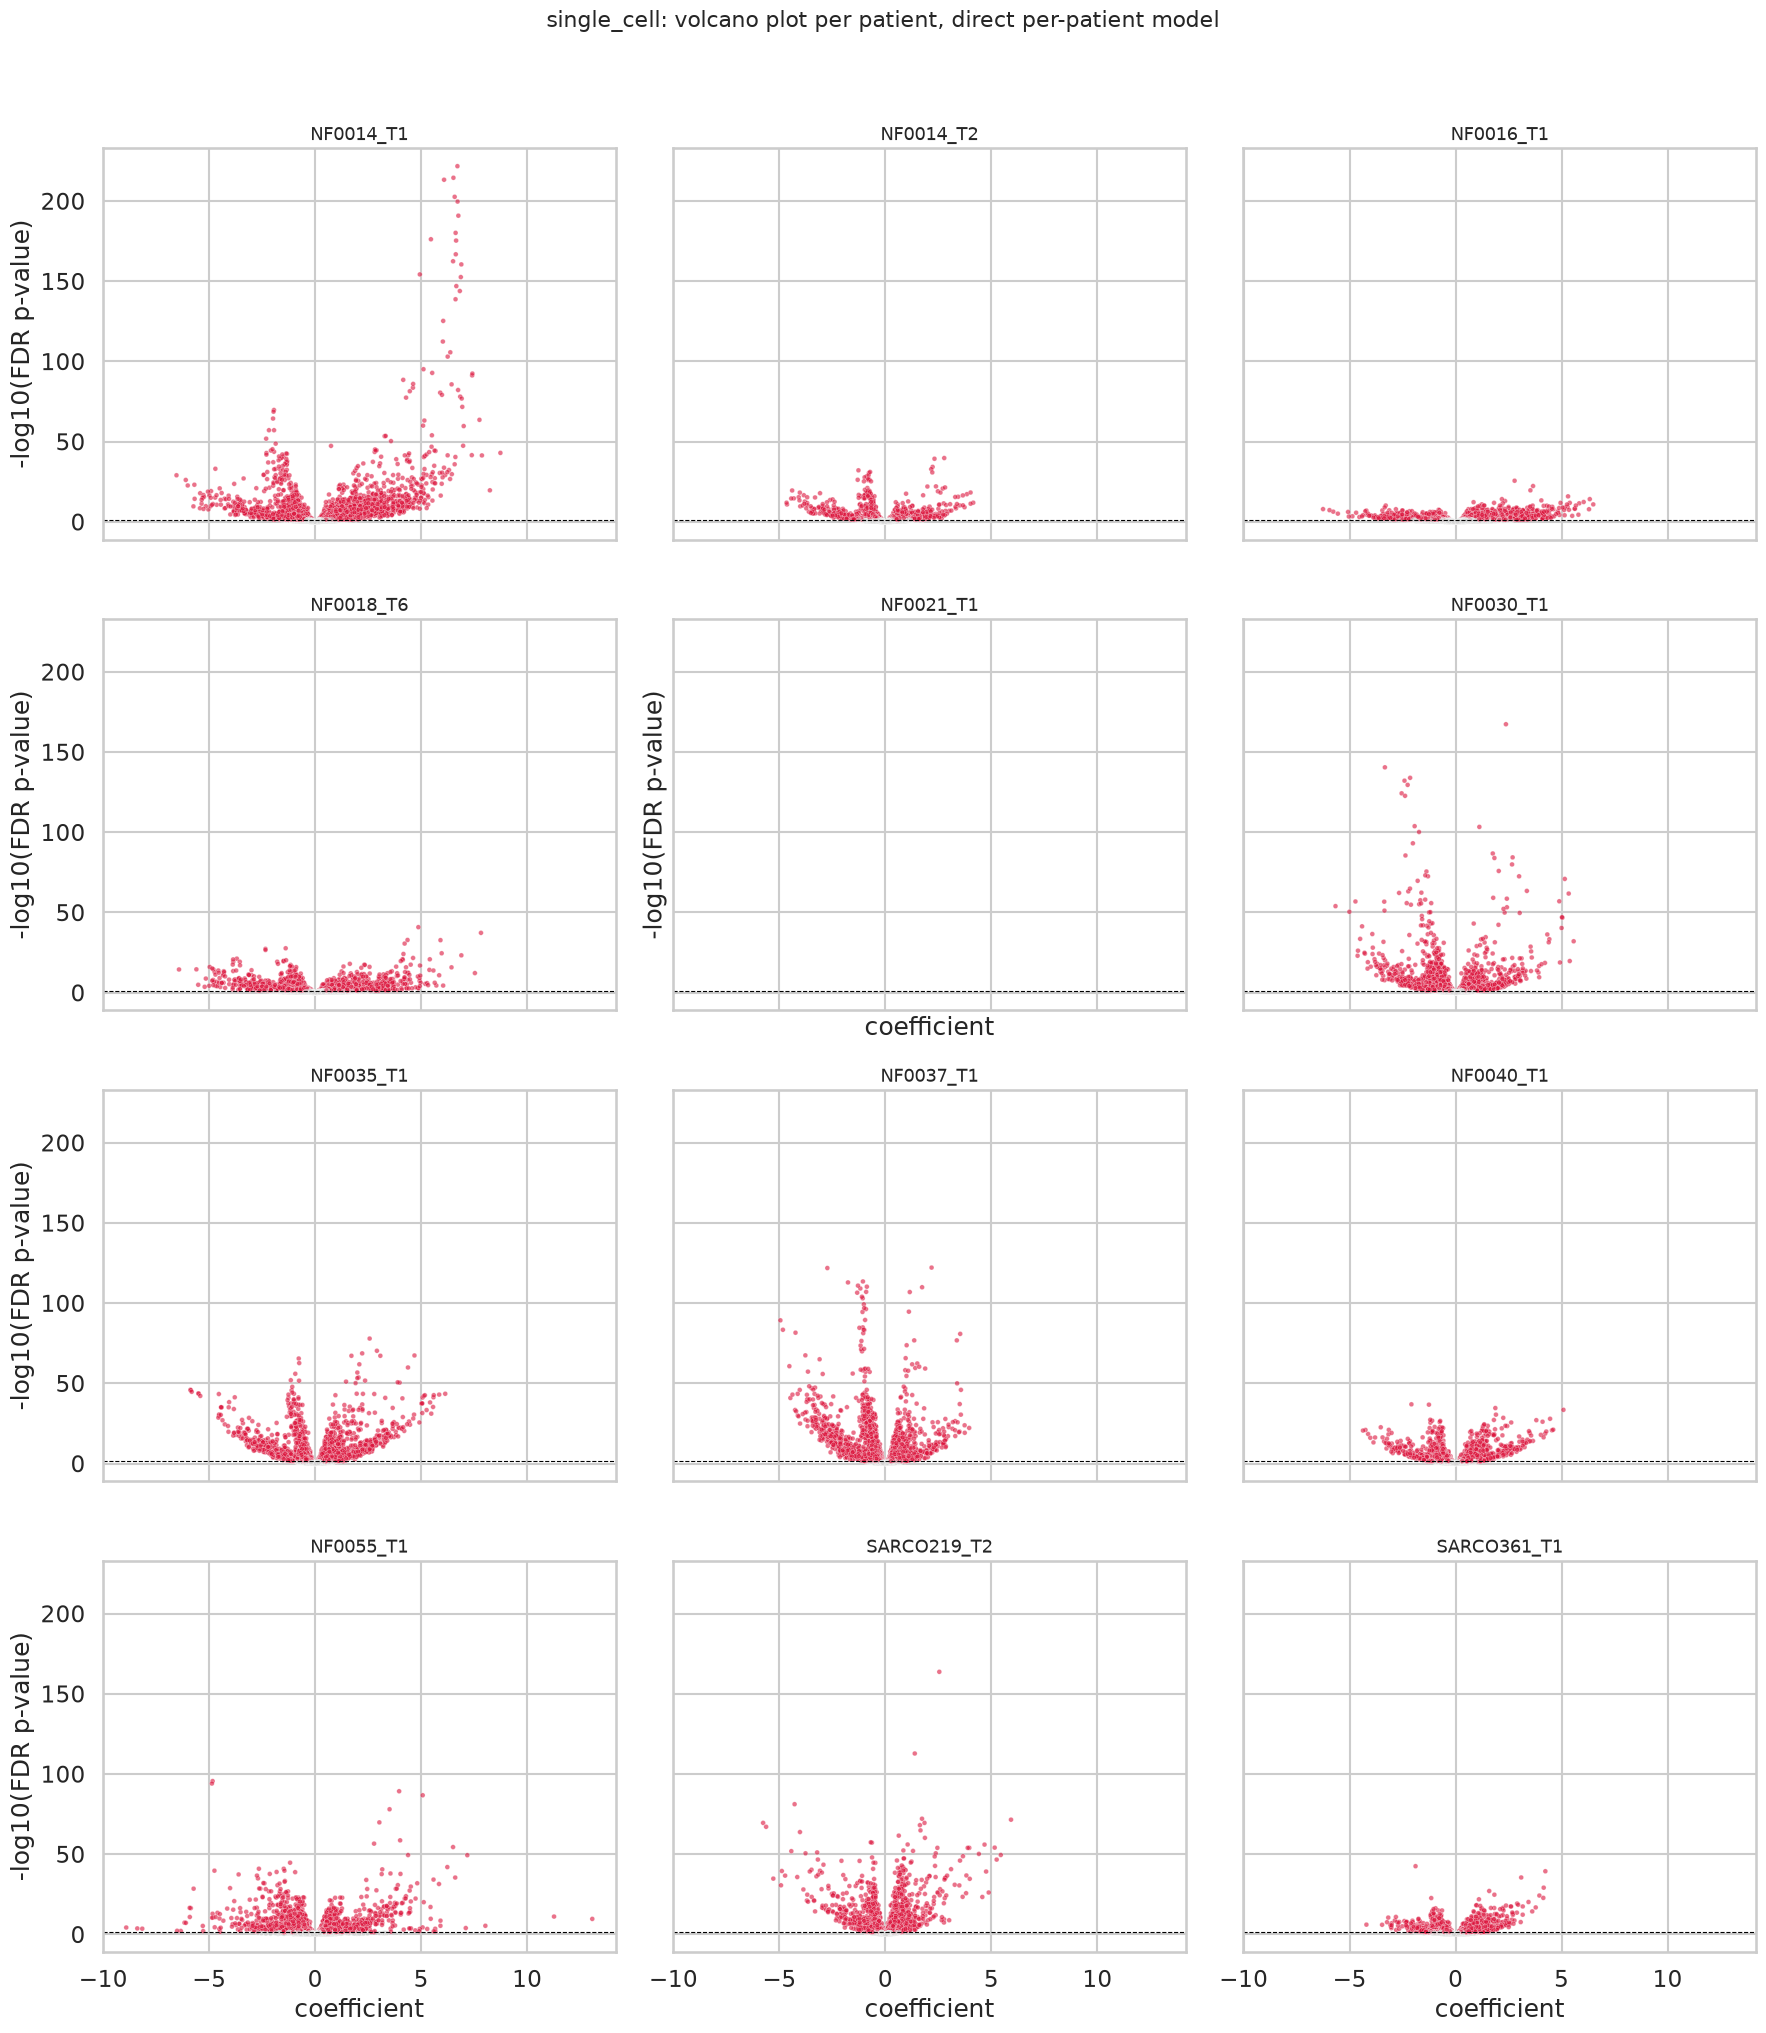

In [2]:
def plot_volcano(df, name):
    patients = sorted(df["patient"].unique())
    n_cols = 3
    n_rows = int(np.ceil(len(patients) / n_cols))
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows), sharex=True, sharey=True
    )
    axes = np.array(axes).reshape(-1)
    for ax, patient in zip(axes, patients):
        pdf = df[df["patient"] == patient]
        sns.scatterplot(
            data=pdf,
            x="coefficient",
            y="neg_log10_pvalue_fdr",
            hue="significant",
            palette={True: "crimson", False: "lightgrey"},
            ax=ax,
            s=12,
            legend=False,
            alpha=0.6,
        )
        ax.axhline(-np.log10(PVALUE_MAX), color="black", linewidth=0.8, linestyle="--")
        ax.set_title(patient, fontsize=13)
        ax.set_xlabel("coefficient")
        ax.set_ylabel("-log10(FDR p-value)")
    for ax in axes[len(patients) :]:
        ax.axis("off")
    fig.suptitle(
        f"{name}: volcano plot per patient, direct per-patient model",
        y=1.02,
        fontsize=16,
    )
    plt.tight_layout()
    plt.savefig(
        figures_path / f"{name}_volcano_by_patient.png", dpi=600, bbox_inches="tight"
    )
    plt.show()


for name, df in coef_dfs.items():
    plot_volcano(df, name)